In [23]:
!pip install matplotlib seaborn pyvis networkx pandas
import pandas as pd
import matplotlib.pyplot as plt
from pyvis.network import Network
import networkx as nx
import seaborn as sns


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
df = pd.read_csv("subreddit_similarity_results.csv")
df

,Subreddit_A,Subreddit_B,Similarity_Score
0,196,19684,0.9989
1,AliexpressCouponFind,AliexpressCoupons2021,0.9986
2,AxieInfinityScholar,AxieScholarshipsPH,0.9971
3,BSCMoonShots,AllCryptoBets,0.9967
4,19684,197,0.9966
...,...,...,...
3225705,BeeSwarmSimulator,BostonRSS,0.3000
3225706,AppleFitnessPlus,4ChanMeta,0.3000
3225707,CosmicDisclosure,Azoozkie,0.3000
3225708,Baddies_of_NC,Bowyer,0.3000


In [25]:
df["Subreddit_A"].unique()

<ArrowStringArray>
[                 '196', 'AliexpressCouponFind',  'AxieInfinityScholar',
         'BSCMoonShots',                '19684',            'CoinSales',
    'CouponCodeExplore',      'AbsoluteWeapons', 'BestPolishInfluencer',
            'CelebLBDs',
 ...
             'CVEWatch',           'BestOfEbay',           'ALLtheNFSW',
          'AfricaVoice',        'ControlTheory',    'ActualidadMundial',
   'AcademicPsychology',             'Angular2',           'BotBustLog',
                 'ACGN']
Length: 3608, dtype: str

In [26]:
df['pair'] = df.apply(lambda row: tuple(sorted([row['Subreddit_A'], row['Subreddit_B']])), axis=1)

df_unique = df.drop_duplicates(subset='pair')

In [27]:
threshold = df['Similarity_Score'].quantile(0.97)

In [28]:
top_pairs = df_unique[df_unique['Similarity_Score'] >= threshold]
top_pairs

,Subreddit_A,Subreddit_B,Similarity_Score,pair
0,196,19684,0.9989,"(196, 19684)"
1,AliexpressCouponFind,AliexpressCoupons2021,0.9986,"(AliexpressCouponFind, AliexpressCoupons2021)"
2,AxieInfinityScholar,AxieScholarshipsPH,0.9971,"(AxieInfinityScholar, AxieScholarshipsPH)"
3,BSCMoonShots,AllCryptoBets,0.9967,"(AllCryptoBets, BSCMoonShots)"
4,19684,197,0.9966,"(19684, 197)"
...,...,...,...,...
96795,CanberraNSFW,Cebu_r4r,0.7361,"(CanberraNSFW, Cebu_r4r)"
96796,CorpusChristiCasuals,Amazingfemale18plus,0.7361,"(Amazingfemale18plus, CorpusChristiCasuals)"
96797,AnimalRestaurant,AvatarMemes,0.7361,"(AnimalRestaurant, AvatarMemes)"
96798,BSCcryptoListings,AltStreetBets,0.7361,"(AltStreetBets, BSCcryptoListings)"


In [29]:
df["Subreddit_A"].unique()

<ArrowStringArray>
[                 '196', 'AliexpressCouponFind',  'AxieInfinityScholar',
         'BSCMoonShots',                '19684',            'CoinSales',
    'CouponCodeExplore',      'AbsoluteWeapons', 'BestPolishInfluencer',
            'CelebLBDs',
 ...
             'CVEWatch',           'BestOfEbay',           'ALLtheNFSW',
          'AfricaVoice',        'ControlTheory',    'ActualidadMundial',
   'AcademicPsychology',             'Angular2',           'BotBustLog',
                 'ACGN']
Length: 3608, dtype: str

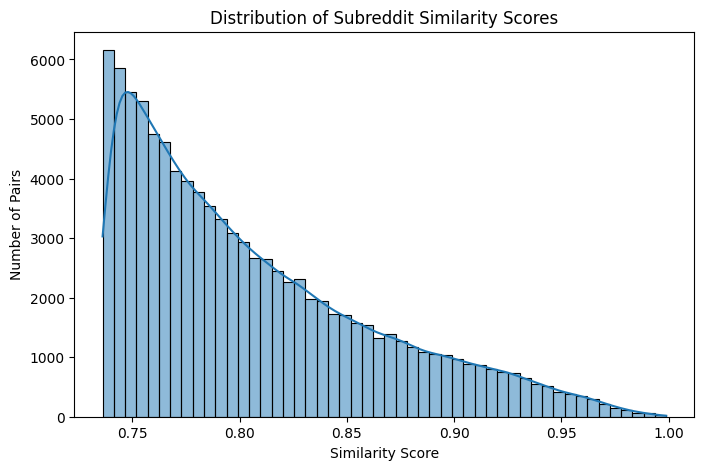

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(top_pairs["Similarity_Score"], bins=50, kde=True)
plt.title("Distribution of Subreddit Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Pairs")
plt.show()

In [31]:
df.sort_values("Similarity_Score", ascending=False).head(30)


,Subreddit_A,Subreddit_B,Similarity_Score,pair
0,196,19684,0.9989,"(196, 19684)"
1,AliexpressCouponFind,AliexpressCoupons2021,0.9986,"(AliexpressCouponFind, AliexpressCoupons2021)"
2,AxieInfinityScholar,AxieScholarshipsPH,0.9971,"(AxieInfinityScholar, AxieScholarshipsPH)"
3,BSCMoonShots,AllCryptoBets,0.9967,"(AllCryptoBets, BSCMoonShots)"
4,19684,197,0.9966,"(19684, 197)"
5,CoinSales,Coins4Sale,0.9965,"(CoinSales, Coins4Sale)"
6,CouponCodeExplore,CouponCodeNews,0.9961,"(CouponCodeExplore, CouponCodeNews)"
7,AbsoluteWeapons,AbsoluteWeaponz,0.9961,"(AbsoluteWeapons, AbsoluteWeaponz)"
8,BestPolishInfluencer,BestPolishNSFW,0.9960,"(BestPolishInfluencer, BestPolishNSFW)"
9,CelebLBDs,CelebrityFeetPosts,0.9958,"(CelebLBDs, CelebrityFeetPosts)"


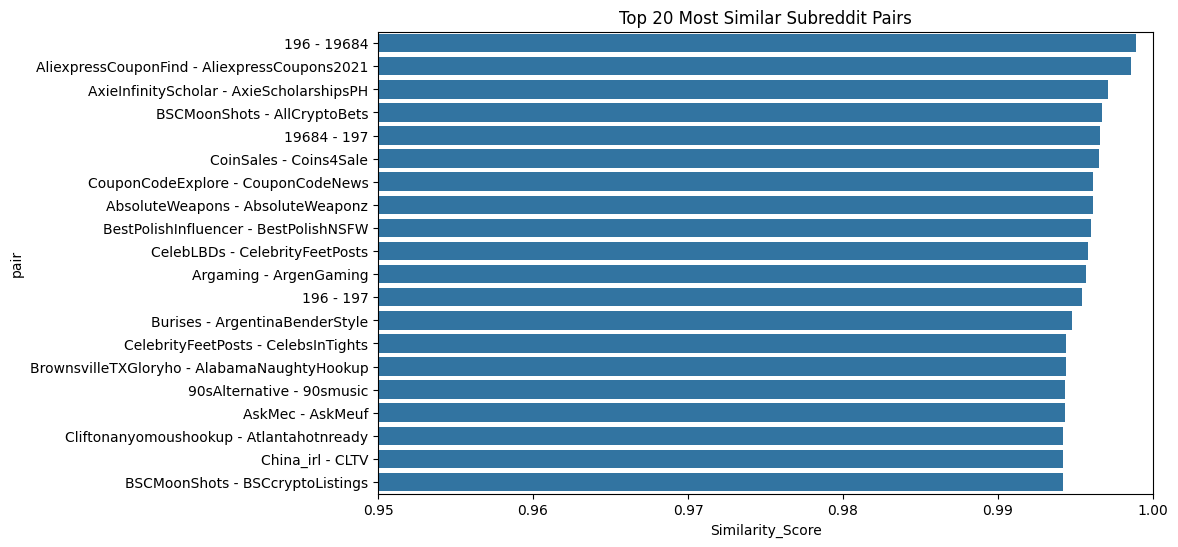

In [32]:

top_pairs["pair"] = top_pairs["Subreddit_A"] + " - " + top_pairs["Subreddit_B"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_pairs.head(20), y="pair", x="Similarity_Score")
plt.title("Top 20 Most Similar Subreddit Pairs")
plt.xlim(0.95, 1.0)
plt.show()


In [33]:
top_nodes = top_pairs.sample(n=4000, random_state=42)

In [34]:
G = nx.from_pandas_edgelist(
    top_nodes,
    source='Subreddit_A',
    target='Subreddit_B',
    edge_attr='Similarity_Score'
)

for u, v, d in G.edges(data=True):
    d['value'] = d['Similarity_Score']
    if d['Similarity_Score'] > 0.85:
        d['color'] = 'red'

degree_dict = dict(G.degree())

for node in G.nodes():
    G.nodes[node]['size'] = max(degree_dict[node] * 3, 5)

net = Network(
    height="800px",
    width="100%",
    bgcolor="#111111",
    font_color="white",
    notebook=False,
    cdn_resources="in_line"
)

net.from_nx(G)
net.force_atlas_2based()

html = net.generate_html()

with open("subreddit_graph.html", "w", encoding="utf-8") as f:
    f.write(html)

In [22]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is connected: {nx.is_connected(G)}")

if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"Number of connected components: {len(components)}")
    largest_cc = max(components, key=len)
    G = G.subgraph(largest_cc).copy()
    print(f"Using largest component with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Number of nodes: 1592
Number of edges: 3788
Is connected: True


In [ ]:
comp = girvan_newman(G)

modularity_scores = []
community_counts = []
communities_list = []

print("Running Girvan-Newman algorithm...")
for i, communities in enumerate(comp):
    communities_tuple = tuple(sorted(c) for c in communities)
    communities_list.append(communities_tuple)
    
    mod = modularity(G, communities)
    modularity_scores.append(mod)
    community_counts.append(len(communities))
    
    print(f"Iteration {i+1}: {len(communities)} communities, Modularity = {mod:.4f}")
    
    if i >= 25:
        break

print(f"\nCompleted {len(modularity_scores)} iterations")

Running Girvan-Newman algorithm...
Iteration 1: 2 communities, Modularity = 0.0383
Iteration 2: 3 communities, Modularity = 0.0733
Iteration 3: 4 communities, Modularity = 0.1450
Iteration 4: 5 communities, Modularity = 0.1684
Iteration 5: 6 communities, Modularity = 0.1765
Iteration 6: 7 communities, Modularity = 0.1821
Iteration 7: 8 communities, Modularity = 0.1873
Iteration 8: 9 communities, Modularity = 0.2197
Iteration 9: 10 communities, Modularity = 0.2238
Iteration 10: 11 communities, Modularity = 0.5509
Iteration 11: 12 communities, Modularity = 0.5525
Iteration 12: 13 communities, Modularity = 0.5541
Iteration 13: 14 communities, Modularity = 0.5576
Iteration 14: 15 communities, Modularity = 0.5595
Iteration 15: 16 communities, Modularity = 0.5605
Iteration 16: 17 communities, Modularity = 0.5629
Iteration 17: 18 communities, Modularity = 0.5649
Iteration 18: 19 communities, Modularity = 0.5656
Iteration 19: 20 communities, Modularity = 0.5663
Iteration 20: 21 communities, Mo

In [35]:
best_idx = modularity_scores.index(max(modularity_scores))
best_communities = communities_list[best_idx]
best_modularity = modularity_scores[best_idx]

print(f"Best modularity: {best_modularity:.4f}")
print(f"Number of communities at best modularity: {len(best_communities)}")
print(f"Iteration: {best_idx + 1}")

Best modularity: 0.5788
Number of communities at best modularity: 22
Iteration: 21
